In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.datasets import LFWPairs
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import random


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import os
from torch.utils.data import Dataset
from PIL import Image

class LFWPairDataset(Dataset):
    def __init__(self, image_dir, pairs_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.pairs = []

        with open(pairs_file, 'r') as f:
            lines = f.readlines()[1:]  # skip header line

            for line in lines:
                parts = line.strip().split()
                if len(parts) == 3:
                    name, idx1, idx2 = parts
                    img1 = os.path.join(image_dir, name, f"{name}_{int(idx1):04d}.jpg")
                    img2 = os.path.join(image_dir, name, f"{name}_{int(idx2):04d}.jpg")
                    self.pairs.append((img1, img2, 1))  # same
                elif len(parts) == 4:
                    name1, idx1, name2, idx2 = parts
                    img1 = os.path.join(image_dir, name1, f"{name1}_{int(idx1):04d}.jpg")
                    img2 = os.path.join(image_dir, name2, f"{name2}_{int(idx2):04d}.jpg")
                    self.pairs.append((img1, img2, 0))  # different

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]
        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label


In [4]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Choose one of the following:
train_dataset = LFWPairDataset(
    image_dir="/home/cse/Documents/NP/datasets/LFW/lfw_funneled",
    pairs_file="/home/cse/Documents/NP/datasets/LFW/pairsDevTrain.txt",
    transform=transform
)

# or for full benchmark:
test_dataset = LFWPairDataset(
    image_dir="/home/cse/Documents/NP/datasets/LFW/lfw_funneled",
    pairs_file="/home/cse/Documents/NP/datasets/LFW/pairsDevTest.txt",
    transform=transform
)
print("Train set size:", len(train_dataset))
print("Test set size:", len(test_dataset))



Train set size: 2200
Test set size: 1000


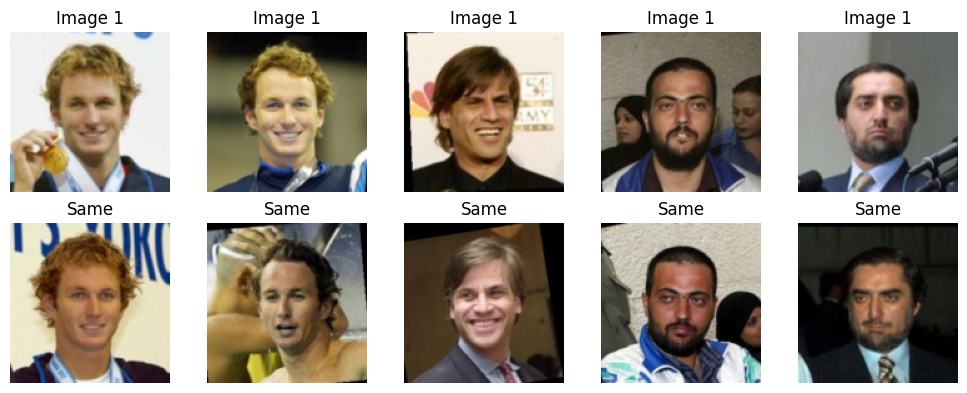

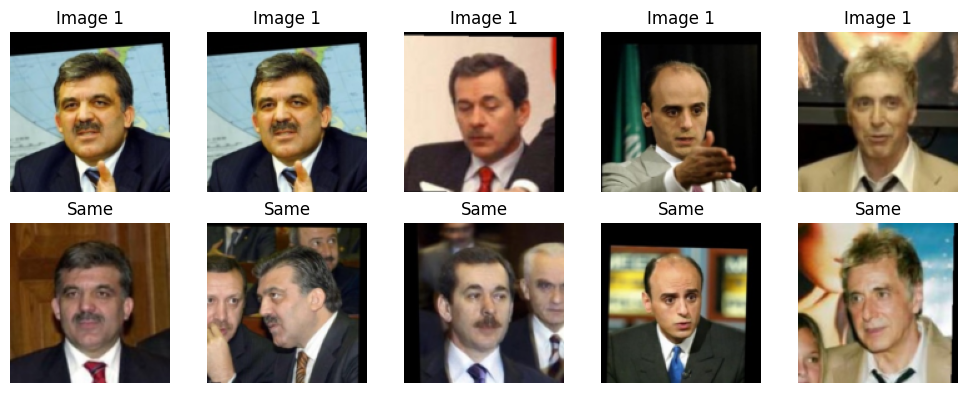

In [5]:
import matplotlib.pyplot as plt

def show_batch(dataset, n=5):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        img1, img2, label = dataset[i]
        img1 = img1.permute(1, 2, 0).numpy()
        img2 = img2.permute(1, 2, 0).numpy()

        plt.subplot(2, n, i + 1)
        plt.imshow(img1)
        plt.axis('off')
        plt.title("Image 1")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(img2)
        plt.axis('off')
        plt.title("Same" if label == 1 else "Different")

    plt.tight_layout()
    plt.show()

# Show some samples
show_batch(train_dataset)
show_batch(test_dataset)



In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==== 1. Base Embedding Network ====
class FaceEmbeddingNet(nn.Module):
    def __init__(self):
        super(FaceEmbeddingNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(128, 128)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# ==== 2. Siamese Network for BCE ====
class SiameseBCEModel(nn.Module):
    def __init__(self, embedding_net):
        super(SiameseBCEModel, self).__init__()
        self.embedding_net = embedding_net

    def forward(self, x1, x2):
        f1 = self.embedding_net(x1)
        f2 = self.embedding_net(x2)
        return F.cosine_similarity(f1, f2).unsqueeze(1)

# ==== 3. Contrastive Loss ====
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        dist = F.pairwise_distance(output1, output2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

# ==== 4. Triplet Loss Dataset Wrapping ====
class TripletDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        anchor_img1, anchor_img2, label = self.dataset[index]
        if label == 1:
            positive = anchor_img2
            negative = self.dataset[(index + 1) % len(self.dataset)][1]
        else:
            positive = self.dataset[(index + 1) % len(self.dataset)][1]
            negative = anchor_img2
        return anchor_img1, positive, negative

In [7]:
def train_bce(model, dataloader, epochs=50):
    model.train()
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for img1, img2, label in dataloader:
            img1, img2 = img1.to(device), img2.to(device)
            label = label.float().unsqueeze(1).to(device)
            pred = torch.sigmoid(model(img1, img2))
            loss = criterion(pred, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"[BCE] Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    return model, losses


In [8]:
def train_contrastive(embedding_net, dataloader, epochs=50):
    embedding_net.train()
    criterion = ContrastiveLoss()
    optimizer = torch.optim.Adam(embedding_net.parameters(), lr=1e-4)
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for img1, img2, label in dataloader:
            img1, img2 = img1.to(device), img2.to(device)
            label = label.float().to(device)
            out1 = embedding_net(img1)
            out2 = embedding_net(img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"[Contrastive] Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    return embedding_net, losses



In [9]:
def train_triplet(embedding_net, dataloader, epochs=50):
    embedding_net.train()
    criterion = nn.TripletMarginLoss(margin=1.0)
    optimizer = torch.optim.Adam(embedding_net.parameters(), lr=1e-4)
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for anchor, positive, negative in dataloader:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)
            anchor_out = embedding_net(anchor)
            pos_out = embedding_net(positive)
            neg_out = embedding_net(negative)
            loss = criterion(anchor_out, pos_out, neg_out)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"[Triplet] Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    return embedding_net, losses

In [10]:
def show_verification(img1, img2, is_same, sim_score):
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(img1.permute(1, 2, 0))
    ax[0].set_title("Image 1")
    ax[1].imshow(img2.permute(1, 2, 0))
    ax[1].set_title(f"Image 2\nSim: {sim_score:.2f}")
    
    border_color = 'green' if is_same else 'red'
    for a in ax:
        a.axis('off')
        for spine in a.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)
    plt.show()


In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data loaders
data_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)
triplet_loader = DataLoader(TripletDataset(train_dataset), batch_size=32, shuffle=True)

In [12]:
bce_model = SiameseBCEModel(FaceEmbeddingNet().to(device))
bce_model, bce_losses = train_bce(bce_model, data_loader)

[BCE] Epoch 1, Loss: 0.7760
[BCE] Epoch 2, Loss: 0.7335
[BCE] Epoch 3, Loss: 0.7289
[BCE] Epoch 4, Loss: 0.7198
[BCE] Epoch 5, Loss: 0.7100
[BCE] Epoch 6, Loss: 0.7124
[BCE] Epoch 7, Loss: 0.7059
[BCE] Epoch 8, Loss: 0.7004
[BCE] Epoch 9, Loss: 0.6951
[BCE] Epoch 10, Loss: 0.6961
[BCE] Epoch 11, Loss: 0.6908
[BCE] Epoch 12, Loss: 0.6912
[BCE] Epoch 13, Loss: 0.6861
[BCE] Epoch 14, Loss: 0.6884
[BCE] Epoch 15, Loss: 0.6790
[BCE] Epoch 16, Loss: 0.6783
[BCE] Epoch 17, Loss: 0.6783
[BCE] Epoch 18, Loss: 0.6771
[BCE] Epoch 19, Loss: 0.6733
[BCE] Epoch 20, Loss: 0.6734
[BCE] Epoch 21, Loss: 0.6780
[BCE] Epoch 22, Loss: 0.6706
[BCE] Epoch 23, Loss: 0.6675
[BCE] Epoch 24, Loss: 0.6708
[BCE] Epoch 25, Loss: 0.6672
[BCE] Epoch 26, Loss: 0.6664
[BCE] Epoch 27, Loss: 0.6634
[BCE] Epoch 28, Loss: 0.6649
[BCE] Epoch 29, Loss: 0.6630
[BCE] Epoch 30, Loss: 0.6637
[BCE] Epoch 31, Loss: 0.6615
[BCE] Epoch 32, Loss: 0.6618
[BCE] Epoch 33, Loss: 0.6628
[BCE] Epoch 34, Loss: 0.6620
[BCE] Epoch 35, Loss: 0

In [13]:
contrastive_net = FaceEmbeddingNet().to(device)
contrastive_net, contrastive_losses = train_contrastive(contrastive_net, data_loader)

[Contrastive] Epoch 1, Loss: 0.3263
[Contrastive] Epoch 2, Loss: 0.2782
[Contrastive] Epoch 3, Loss: 0.2756
[Contrastive] Epoch 4, Loss: 0.2734
[Contrastive] Epoch 5, Loss: 0.2712
[Contrastive] Epoch 6, Loss: 0.2703
[Contrastive] Epoch 7, Loss: 0.2647
[Contrastive] Epoch 8, Loss: 0.2582
[Contrastive] Epoch 9, Loss: 0.2555
[Contrastive] Epoch 10, Loss: 0.2555
[Contrastive] Epoch 11, Loss: 0.2537
[Contrastive] Epoch 12, Loss: 0.2517
[Contrastive] Epoch 13, Loss: 0.2502
[Contrastive] Epoch 14, Loss: 0.2489
[Contrastive] Epoch 15, Loss: 0.2472
[Contrastive] Epoch 16, Loss: 0.2466
[Contrastive] Epoch 17, Loss: 0.2465
[Contrastive] Epoch 18, Loss: 0.2443
[Contrastive] Epoch 19, Loss: 0.2425
[Contrastive] Epoch 20, Loss: 0.2431
[Contrastive] Epoch 21, Loss: 0.2397
[Contrastive] Epoch 22, Loss: 0.2396
[Contrastive] Epoch 23, Loss: 0.2394
[Contrastive] Epoch 24, Loss: 0.2376
[Contrastive] Epoch 25, Loss: 0.2375
[Contrastive] Epoch 26, Loss: 0.2368
[Contrastive] Epoch 27, Loss: 0.2356
[Contrasti

In [14]:
triplet_net = FaceEmbeddingNet().to(device)
triplet_net, triplet_losses = train_triplet(triplet_net, triplet_loader)

[Triplet] Epoch 1, Loss: 0.9973
[Triplet] Epoch 2, Loss: 0.9904
[Triplet] Epoch 3, Loss: 0.9818
[Triplet] Epoch 4, Loss: 0.9792
[Triplet] Epoch 5, Loss: 0.9769
[Triplet] Epoch 6, Loss: 0.9733
[Triplet] Epoch 7, Loss: 0.9705
[Triplet] Epoch 8, Loss: 0.9697
[Triplet] Epoch 9, Loss: 0.9651
[Triplet] Epoch 10, Loss: 0.9639
[Triplet] Epoch 11, Loss: 0.9649
[Triplet] Epoch 12, Loss: 0.9591
[Triplet] Epoch 13, Loss: 0.9619
[Triplet] Epoch 14, Loss: 0.9558
[Triplet] Epoch 15, Loss: 0.9548
[Triplet] Epoch 16, Loss: 0.9548
[Triplet] Epoch 17, Loss: 0.9534
[Triplet] Epoch 18, Loss: 0.9555
[Triplet] Epoch 19, Loss: 0.9523
[Triplet] Epoch 20, Loss: 0.9532
[Triplet] Epoch 21, Loss: 0.9505
[Triplet] Epoch 22, Loss: 0.9483
[Triplet] Epoch 23, Loss: 0.9491
[Triplet] Epoch 24, Loss: 0.9455
[Triplet] Epoch 25, Loss: 0.9471
[Triplet] Epoch 26, Loss: 0.9467
[Triplet] Epoch 27, Loss: 0.9431
[Triplet] Epoch 28, Loss: 0.9462
[Triplet] Epoch 29, Loss: 0.9471
[Triplet] Epoch 30, Loss: 0.9430
[Triplet] Epoch 31,

In [15]:
def plot_losses(bce, contrastive, triplet):
    plt.plot(bce, label="BCE Loss")
    plt.plot(contrastive, label="Contrastive Loss")
    plt.plot(triplet, label="Triplet Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curves for Different Objectives")
    plt.legend()
    plt.grid()
    plt.show()

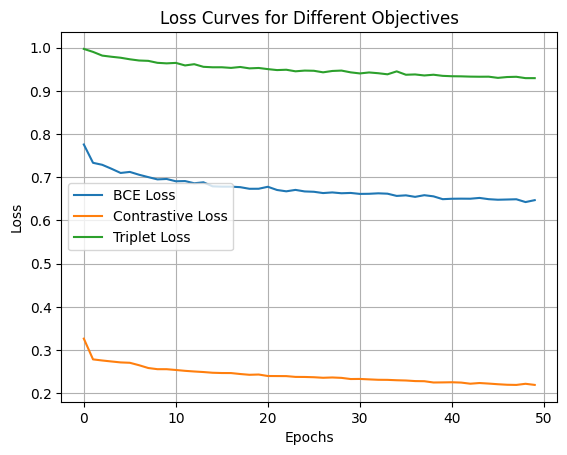

In [16]:
# ==== 9. Plot Comparison ====
plot_losses(bce_losses, contrastive_losses, triplet_losses)

In [17]:
import matplotlib.pyplot as plt

def show_verification(img1, img2, is_same, sim_score):
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))
    ax[0].imshow(img1.permute(1, 2, 0))
    ax[0].set_title("Image 1")
    ax[0].axis('off')
    
    ax[1].imshow(img2.permute(1, 2, 0))
    ax[1].set_title(f"Image 2\nSim: {sim_score:.2f}")
    ax[1].axis('off')
    
    border_color = 'green' if is_same else 'red'
    for a in ax:
        for spine in a.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)
    plt.show()


In [18]:
def evaluate_and_verify_bce(model, dataset, dataloader, index=0, threshold=0.5):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for img1, img2, label in dataloader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            outputs = torch.sigmoid(model(img1, img2))
            preds = (outputs > threshold).float()
            correct += (preds.squeeze() == label).sum().item()
            total += label.size(0)
    accuracy = correct / total
    print(f"BCE Model Accuracy: {accuracy*100:.2f}%")
    
    # Show verification for one sample
    img1, img2, label = dataset[index]
    with torch.no_grad():
        sim = torch.sigmoid(model(img1.unsqueeze(0).to(device), img2.unsqueeze(0).to(device))).item()
    is_same = sim > threshold
    show_verification(img1, img2, is_same, sim)


def evaluate_and_verify_contrastive(model, dataset, dataloader, index=0, margin=1.0):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for img1, img2, label in dataloader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            emb1 = model(img1)
            emb2 = model(img2)
            distances = torch.nn.functional.pairwise_distance(emb1, emb2)
            preds = (distances < margin).float()
            correct += (preds == (label == 0).float()).sum().item()  # label==0 means same person
            total += label.size(0)
    accuracy = correct / total
    print(f"Contrastive Model Accuracy: {accuracy*100:.2f}%")

    # Show verification for one sample
    img1, img2, label = dataset[index]
    with torch.no_grad():
        emb1 = model(img1.unsqueeze(0).to(device))
        emb2 = model(img2.unsqueeze(0).to(device))
        distance = torch.nn.functional.pairwise_distance(emb1, emb2).item()
    is_same = distance < margin
    sim = 1 - distance
    show_verification(img1, img2, is_same, sim)


def evaluate_and_verify_triplet(model, dataset, dataloader, index=0, margin=1.0):
    model.eval()
    # Triplet accuracy same as contrastive for evaluation here
    correct = 0
    total = 0
    with torch.no_grad():
        for img1, img2, label in dataloader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            emb1 = model(img1)
            emb2 = model(img2)
            distances = torch.nn.functional.pairwise_distance(emb1, emb2)
            preds = (distances < margin).float()
            correct += (preds == (label == 0).float()).sum().item()
            total += label.size(0)
    accuracy = correct / total
    print(f"Triplet Model Accuracy: {accuracy*100:.2f}%")

    # Show verification for one sample
    img1, img2, label = dataset[index]
    with torch.no_grad():
        emb1 = model(img1.unsqueeze(0).to(device))
        emb2 = model(img2.unsqueeze(0).to(device))
        distance = torch.nn.functional.pairwise_distance(emb1, emb2).item()
    is_same = distance < margin
    sim = 1 - distance
    show_verification(img1, img2, is_same, sim)


BCE Model Accuracy: 55.10%


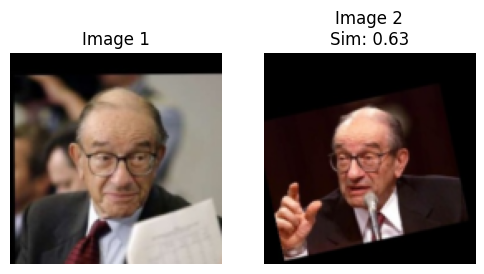

Contrastive Model Accuracy: 49.40%


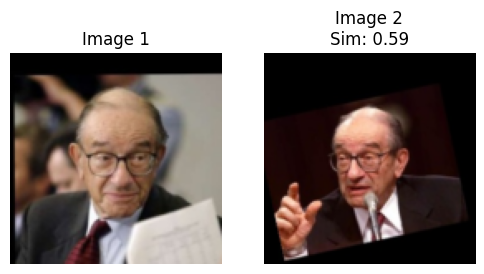

Triplet Model Accuracy: 47.20%


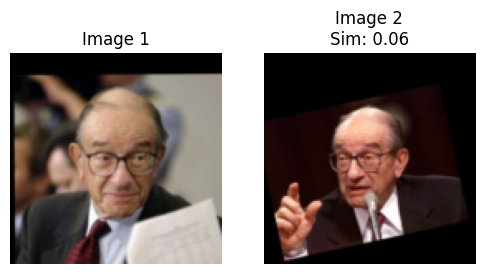

In [22]:
evaluate_and_verify_bce(bce_model, test_dataset, test_loader, index=5)
evaluate_and_verify_contrastive(contrastive_net, test_dataset, test_loader, index=5)
evaluate_and_verify_triplet(triplet_net, test_dataset, test_loader, index=5)
